In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/LA_AQS_2023.csv') # the slash indicates the path where the dataset is. 


In [7]:
df['Parameter Name']

0           Ambient Min Temperature
1            Nitrogen dioxide (NO2)
2                 Relative Humidity
3               Outdoor Temperature
4          Oxides of nitrogen (NOx)
                    ...            
22155               Solar radiation
22156    Wind Direction - Resultant
22157        Wind Speed - Resultant
22158             Relative Humidity
22159           Outdoor Temperature
Name: Parameter Name, Length: 22160, dtype: object

In [13]:
df_O3 = df[(df['Parameter Name'] == 'Ozone') & (df['Duration Description']=='1 HOUR')]
df_O3.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
228,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
271,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [19]:
df_O3["Date (Local)"] = pd.to_datetime(df_O3["Date (Local)"])
df_O3["Date (Local)"]

20      2023-01-01
64      2023-01-02
204     2023-01-03
228     2023-01-04
271     2023-01-05
           ...    
21122   2023-09-26
21168   2023-09-27
21218   2023-09-28
21261   2023-09-29
21305   2023-09-30
Name: Date (Local), Length: 273, dtype: datetime64[ns]

In [31]:
date = df_O3["Date (Local)"]
value = df_O3["Arithmetic Mean"]

Text(0, 0.5, 'Ozone Arithmetic Mean')

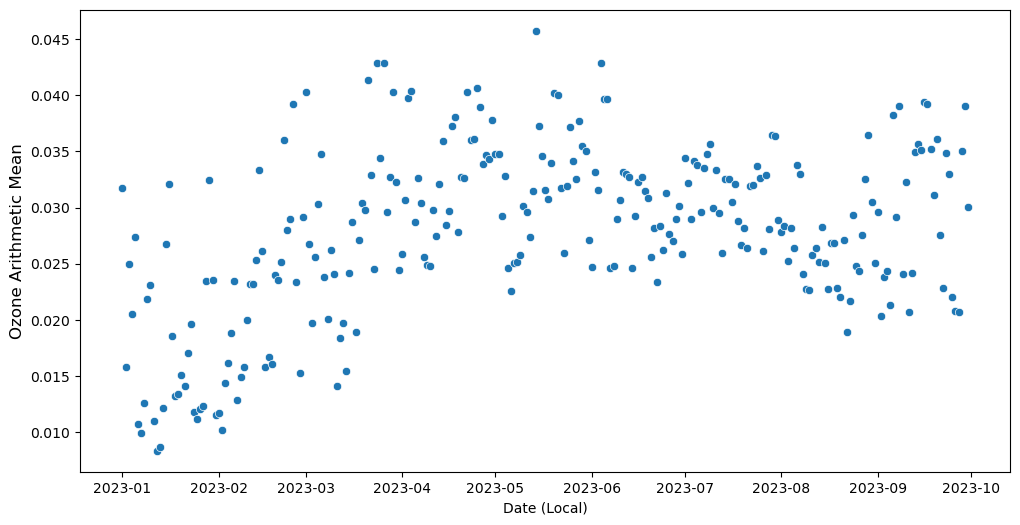

In [47]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=date, y=value)
plt.ylabel("Ozone Arithmetic Mean", fontsize=12)

In [41]:
# When is O3 highest at this monitor?

df_O3.loc[df_O3["Arithmetic Mean"].idxmax(), "Date (Local)"]

#ans = Timestamp('2023-05-14 00:00:00')

Timestamp('2023-05-14 00:00:00')

In [69]:
# How many days have O3 concentrations above 35 ppbv?

value_ppb = value*1000 # data given in ppm, but need in ppb
results = value_ppb>35

results.value_counts() # if true, then it satisfies the value_ppb>35, so its a day greater than 35 ppbv

#ans = 43

Arithmetic Mean
False    230
True      43
Name: count, dtype: int64